In [1]:
import os
import numpy as np
import yaml
import matplotlib.pyplot as plt
import healpy as hp
import heracles
import heracles.dices as dices
from heracles.io import read

# SpaceBorne Vs DICES

In [2]:
config_path = "scripts/sims_config.yaml"
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)
n = config['nsims']
nside = config['nside']
lmax = config['lmax']
mode = config['mode']  # "lognormal" or "gaussian"
binned = False #True
apply_mask = True
nbins = 3

output_path = f"{mode}_dices/"
output_path = "./masked_"+output_path

nlbins = 10
l = np.arange(lmax+1)
ls = np.arange(lmax+1)
ledges = np.logspace(np.log10(10), np.log10(lmax), nlbins + 1)
lgrid = (ledges[1:] + ledges[:-1]) / 2

## Comparison

In [ ]:
path = f"./{mode}_sims/"
cls = {}
inv_cls = {}
nu_cls = {}
pp_cls = {}
pm_cls = {}
for i in range(1, n+1):
    print(f"Loading sim {i}", end='\r')
    cls[i] = heracles.read(path+f"/cls/cls_data_{i}.fits")
    inv_cls[i] = heracles.read(path+f"/cls_inv/cls_data_inv_{i}.fits")
    nu_cls[i] = heracles.read(path+f"/cls_nu/cls_data_nu_{i}.fits")
    pp_cls[i] = heracles.read(path+f"/cls_pp/cls_data_pp_{i}.fits")
    pm_cls[i] = heracles.read(path+f"/cls_pm/cls_data_pm_{i}.fits")

In [4]:
def get_cls_mean(cls_dict):
    n_keys = list(cls_dict.keys())
    f_keys = list(cls_dict[n_keys[0]].keys())
    cls_mean = {}
    for f_key in f_keys:
        cl = np.mean([cls_dict[i][f_key] for i in n_keys], axis=0)
        cls_mean[f_key] = heracles.Result(cl, axis=cls_dict[n_keys[0]][f_key].axis)
    return cls_mean

In [5]:
cls0 = get_cls_mean(cls)
inv_cls_m = get_cls_mean(inv_cls)
nu_cls_m = get_cls_mean(nu_cls)
pp_cls_m = get_cls_mean(pp_cls)
pm_cls_m = get_cls_mean(pm_cls)

cqs0 = heracles.binned(cls0, ledges)
inv_cqs_m = heracles.binned(inv_cls_m, ledges)
nu_cqs_m = heracles.binned(nu_cls_m, ledges)
pp_cqs_m = heracles.binned(pp_cls_m, ledges)
pm_cqs_m = heracles.binned(pm_cls_m, ledges)

In [6]:
theory_cls = heracles.read(f"{mode}_sims/cls/cls_theory.fits")

fl = -np.sqrt((ls+2)*(ls+1)*ls*(ls-1))
fl /= np.clip(ls*(ls+1), 1, None)

_theory_cls = {}
_theory_cls[("POS", "POS", 1, 1)] = heracles.Result(theory_cls["W1xW1"].array, ell=ls)

c = np.zeros((2, 2, lmax+1))
c[0, 0, :] = theory_cls["W2xW2"].array * fl**2
_theory_cls[("SHE", "SHE", 1, 1)] = heracles.Result(c)

c = np.zeros((2, lmax+1))
c[0, :] = theory_cls["W1xW2"].array * fl
_theory_cls[("POS", "SHE", 1, 1)] = heracles.Result(c)

_theory_cqs = heracles.binned(_theory_cls, ledges)


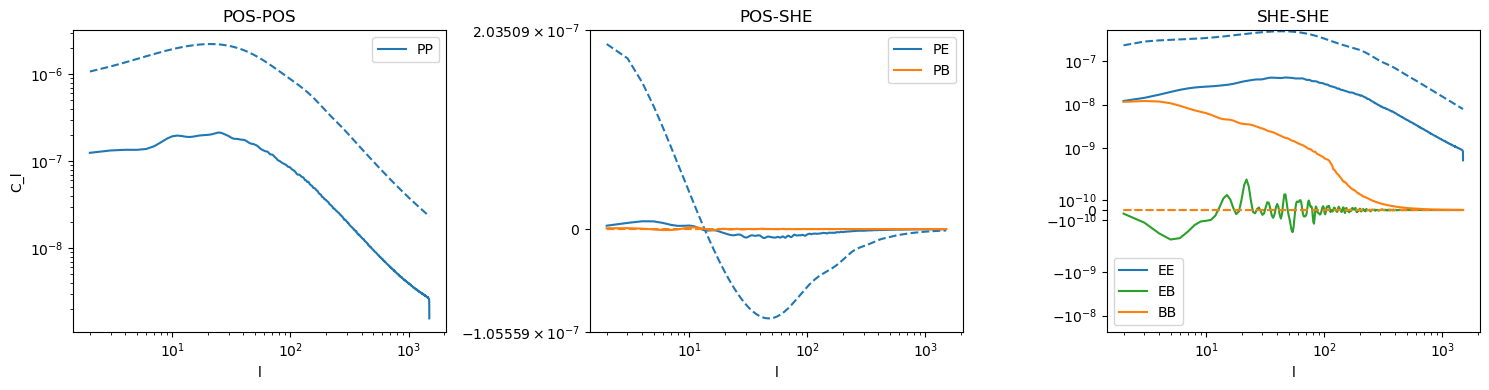

In [7]:
# Create a figure with 1 row and 3 columns of subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 4))  # 1 row, 3 columns

# POS POS
axs[0].plot(l[2:], cls0[("POS", "POS", 1, 1)].array[2:], color='C0', label='PP')
axs[0].plot(l[2:], _theory_cls[("POS", "POS", 1, 1)].array[2:], color='C0', linestyle='--')
axs[0].legend()
axs[0].set_title("POS-POS")
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel("l")
axs[0].set_ylabel("C_l")

# POS SHE
axs[1].plot(l[2:], cls0[("POS", "SHE", 1, 1)].array[0][2:], color='C0', label='PE')
axs[1].plot(l[2:], _theory_cls[("POS", "SHE", 1, 1)].array[0][2:], color='C0', linestyle='--')
axs[1].plot(l[2:], cls0[("POS", "SHE", 1, 1)].array[1][2:], color='C1', label='PB')
axs[1].plot(l[2:], _theory_cls[("POS", "SHE", 1, 1)].array[1][2:], color='C1', linestyle='--')
axs[1].legend()
axs[1].set_title("POS-SHE")
axs[1].set_xscale('log')
axs[1].set_yscale('symlog')
axs[1].set_xlabel("l")

# SHE SHE
axs[2].plot(l[2:], cls0[("SHE", "SHE", 1, 1)].array[0, 0][2:], color='C0', label='EE')
axs[2].plot(l[2:], _theory_cls[("SHE", "SHE", 1, 1)].array[0, 0][2:], color='C0', linestyle='--')
axs[2].plot(l[2:], cls0[("SHE", "SHE", 1, 1)].array[0, 1][2:], color='C2', label='EB')
axs[2].plot(l[2:], _theory_cls[("SHE", "SHE", 1, 1)].array[0, 1][2:], color='C2', linestyle='--')
axs[2].plot(l[2:], cls0[("SHE", "SHE", 1, 1)].array[1, 1][2:], color='C1', label='BB')
axs[2].plot(l[2:], _theory_cls[("SHE", "SHE", 1, 1)].array[1, 1][2:], color='C1', linestyle='--')
axs[2].legend()
axs[2].set_title("SHE-SHE")
axs[2].set_xscale('log')
axs[2].set_yscale('symlog', linthresh=5e-10)
axs[2].set_xlabel("l")

# Adjust layout
plt.tight_layout()
plt.show()

In [8]:
ensemble_cov = heracles.read(f"{mode}_sims/covs/cov_cls.fits")
ensemble_covqq = heracles.read(f"{mode}_sims/covs/cov_cqs.fits")

In [9]:
inv_ensemble_cov = heracles.read(f"{mode}_sims/covs/cov_inv_cls.fits")
nu_ensemble_cov = heracles.read(f"{mode}_sims/covs/cov_nu_cls.fits")
pp_ensemble_cov = heracles.read(f"{mode}_sims/covs/cov_pp_cls.fits")
pm_ensemble_cov = heracles.read(f"{mode}_sims/covs/cov_pm_cls.fits")

inv_ensemble_covqq = heracles.read(f"{mode}_sims/covs/cov_inv_cqs.fits")
nu_ensemble_covqq = heracles.read(f"{mode}_sims/covs/cov_nu_cqs.fits")
pp_ensemble_covqq = heracles.read(f"{mode}_sims/covs/cov_pp_cqs.fits")
pm_ensemble_covqq = heracles.read(f"{mode}_sims/covs/cov_pm_cqs.fits")


In [10]:
# Flattened ensemble Covariance
flat_ensemble_cov = dices.flatten(ensemble_covqq)
flat_ensemble_corr = flat_ensemble_cov / np.sqrt(
    np.diag(flat_ensemble_cov)[:, None] * np.diag(flat_ensemble_cov)[None, :]
)
# Flattened inverse Covariance
flat_inv_ensemble_cov = dices.flatten(inv_ensemble_covqq)
flat_inv_ensemble_corr = flat_inv_ensemble_cov / np.sqrt(
    np.diag(flat_inv_ensemble_cov)[:, None] * np.diag(flat_inv_ensemble_cov)[None, :]
)
# Flattened nu ensemble Covariance
flat_nu_ensemble_cov = dices.flatten(nu_ensemble_covqq)
flat_nu_ensemble_corr = flat_nu_ensemble_cov / np.sqrt(
    np.diag(flat_nu_ensemble_cov)[:, None] * np.diag(flat_nu_ensemble_cov)[None, :]
)
# Flattened PolSpice plus Covariance
flat_pp_ensemble_cov = dices.flatten(pp_ensemble_covqq)
flat_pp_ensemble_corr = flat_pp_ensemble_cov / np.sqrt(
    np.diag(flat_pp_ensemble_cov)[:, None] * np.diag(flat_pp_ensemble_cov)[None, :]
)
# Flattened PolSpice minus Covariance
flat_pm_ensemble_cov = dices.flatten(pm_ensemble_covqq)
flat_pm_ensemble_corr = flat_pm_ensemble_cov / np.sqrt(
    np.diag(flat_pm_ensemble_cov)[:, None] * np.diag(flat_pm_ensemble_cov)[None, :]
)

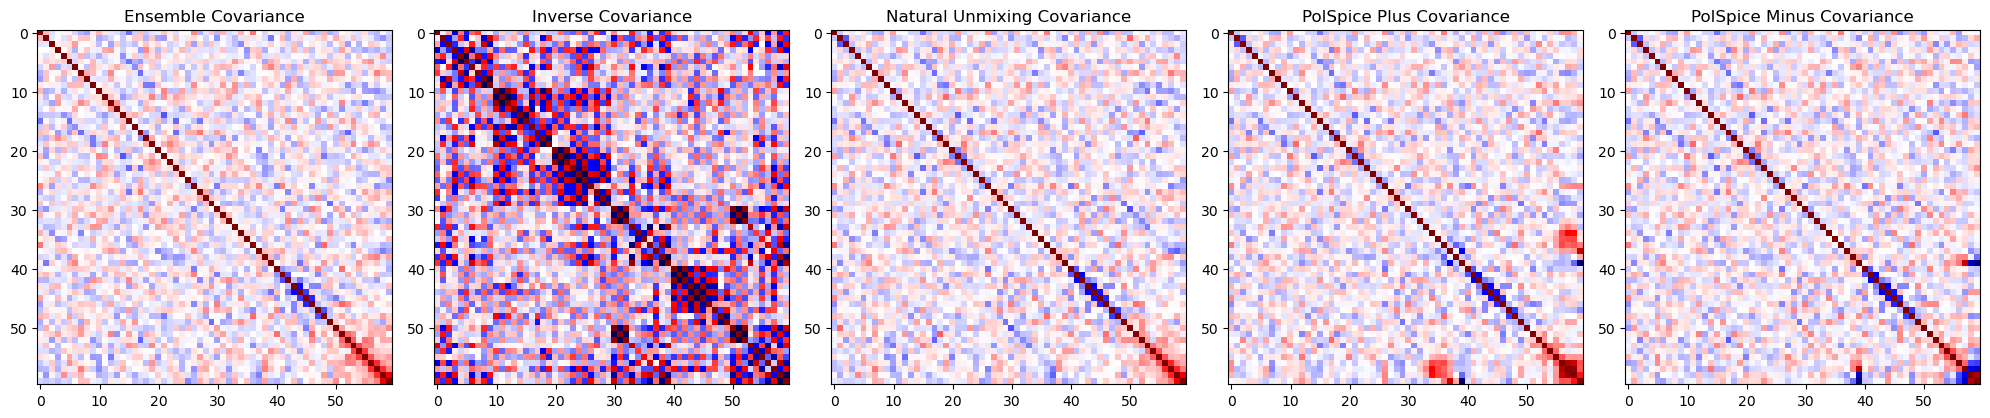

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(20, 15))

# Flattened Ensemble Covariance
im1 = axes[0].imshow(flat_ensemble_corr, cmap="seismic", vmin=-1, vmax=1)
axes[0].set_title("Ensemble Covariance")

# Flattened Inverse covariance
im2 = axes[1].imshow(flat_inv_ensemble_corr, cmap="seismic", vmin=-1, vmax=1)
axes[1].set_title("Inverse Covariance")

# Flattened Natural unmixing Covariance
im3 = axes[2].imshow(flat_nu_ensemble_corr, cmap="seismic", vmin=-1, vmax=1)
axes[2].set_title("Natural Unmixing Covariance")

# Flattened PolSpice Plus Covariance
im3 = axes[3].imshow(flat_pp_ensemble_corr, cmap="seismic", vmin=-1, vmax=1)
axes[3].set_title("PolSpice Plus Covariance")

# Flattened PolSpice Minus Covariance
im3 = axes[4].imshow(flat_pm_ensemble_corr, cmap="seismic", vmin=-1, vmax=1)
axes[4].set_title("PolSpice Minus Covariance")

plt.tight_layout()
plt.show()

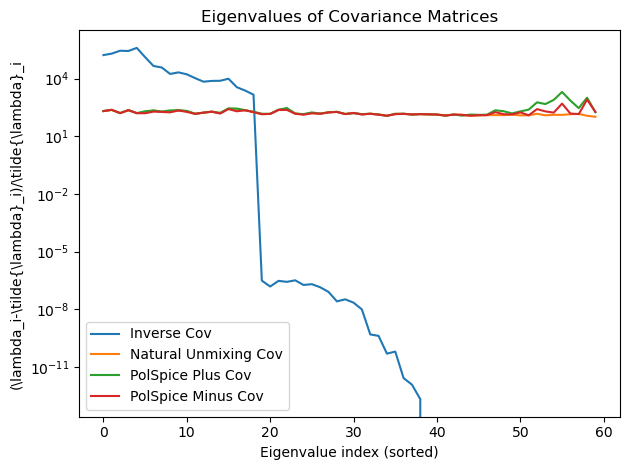

In [12]:
# Compute eigenvalues
eig_ens = np.linalg.eigvalsh(flat_ensemble_cov)
eig_inv_ens = np.linalg.eigvalsh(flat_inv_ensemble_cov)
eig_nu_ens = np.linalg.eigvalsh(flat_nu_ensemble_cov)
eig_pp_ens = np.linalg.eigvalsh(flat_pp_ensemble_cov)
eig_pm_ens = np.linalg.eigvalsh(flat_pm_ensemble_cov)

# Sort eigenvalues for plotting
eig_ens_sorted = np.sort(eig_ens)[::-1]
eig_inv_ens_sorted = np.sort(eig_inv_ens)[::-1]
eig_nu_ens_sorted = np.sort(eig_nu_ens)[::-1]
eig_pp_ens_sorted = np.sort(eig_pp_ens)[::-1]
eig_pm_ens_sorted = np.sort(eig_pm_ens)[::-1]

#plt.figure(figsize=(8, 6))
#plt.semilogy(eig_ens_sorted, label='Ensemble Cov')
plt.semilogy(eig_inv_ens_sorted/eig_ens_sorted, label='Inverse Cov')
plt.semilogy(eig_nu_ens_sorted/eig_ens_sorted, label='Natural Unmixing Cov')
plt.semilogy(eig_pp_ens_sorted/eig_ens_sorted, label='PolSpice Plus Cov')
plt.semilogy(eig_pm_ens_sorted/eig_ens_sorted, label='PolSpice Minus Cov')
plt.xlabel('Eigenvalue index (sorted)')
plt.ylabel(r'(\lambda_i-\tilde{\lambda}_i)/\tilde{\lambda}_i')
plt.title('Eigenvalues of Covariance Matrices')
plt.legend()
plt.tight_layout()
plt.show()

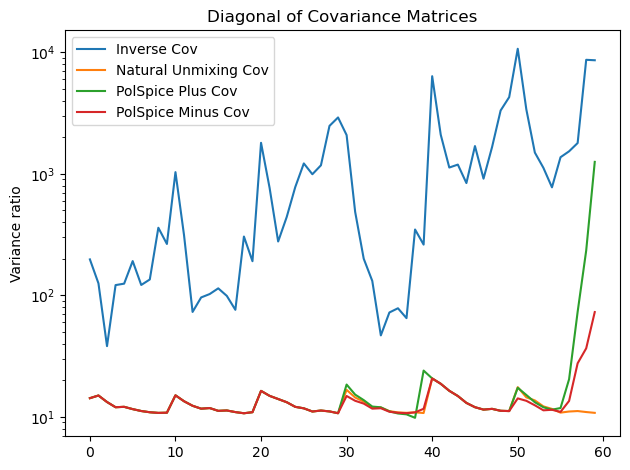

In [41]:
# Compute eigenvalues
ens_err = np.sqrt(np.diag(flat_ensemble_cov))
inv_ens_err = np.sqrt(np.diag(flat_inv_ensemble_cov))
nu_ens_err = np.sqrt(np.diag(flat_nu_ensemble_cov))
pp_ens_err = np.sqrt(np.diag(flat_pp_ensemble_cov))
pm_ens_err = np.sqrt(np.diag(flat_pm_ensemble_cov))


#plt.figure(figsize=(8, 6))
#plt.semilogy(eig_ens_sorted, label='Ensemble Cov')
plt.semilogy(inv_ens_err/ens_err, label='Inverse Cov')
plt.semilogy(nu_ens_err/ens_err, label='Natural Unmixing Cov')
plt.semilogy(pp_ens_err/ens_err, label='PolSpice Plus Cov')
plt.semilogy(pm_ens_err/ens_err, label='PolSpice Minus Cov')
plt.ylabel('Variance ratio')
plt.title('Diagonal of Covariance Matrices')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Compute eigenvalues
eig_ens = np.linalg.eigvalsh(flat_ensemble_cov)
eig_inv_ens = np.linalg.eigvalsh(flat_inv_ensemble_cov)
eig_nu_ens = np.linalg.eigvalsh(flat_nu_ensemble_cov)
eig_pp_ens = np.linalg.eigvalsh(flat_pp_ensemble_cov)
eig_pm_ens = np.linalg.eigvalsh(flat_pm_ensemble_cov)

# Sort eigenvalues for plotting
eig_ens_sorted = np.sort(eig_ens)[::-1]
eig_inv_ens_sorted = np.sort(eig_inv_ens)[::-1]
eig_nu_ens_sorted = np.sort(eig_nu_ens)[::-1]
eig_pp_ens_sorted = np.sort(eig_pp_ens)[::-1]
eig_pm_ens_sorted = np.sort(eig_pm_ens)[::-1]

#plt.figure(figsize=(8, 6))
#plt.semilogy(eig_ens_sorted, label='Ensemble Cov')
plt.semilogy(eig_inv_ens_sorted/eig_ens_sorted, label='Inverse Cov')
plt.semilogy(eig_nu_ens_sorted/eig_ens_sorted, label='Natural Unmixing Cov')
plt.semilogy(eig_pp_ens_sorted/eig_ens_sorted, label='PolSpice Plus Cov')
plt.semilogy(eig_pm_ens_sorted/eig_ens_sorted, label='PolSpice Minus Cov')
plt.xlabel('Eigenvalue index (sorted)')
plt.ylabel(r'(\lambda_i-\tilde{\lambda}_i)/\tilde{\lambda}_i')
plt.title('Eigenvalues of Covariance Matrices')
plt.legend()
plt.tight_layout()
plt.show()

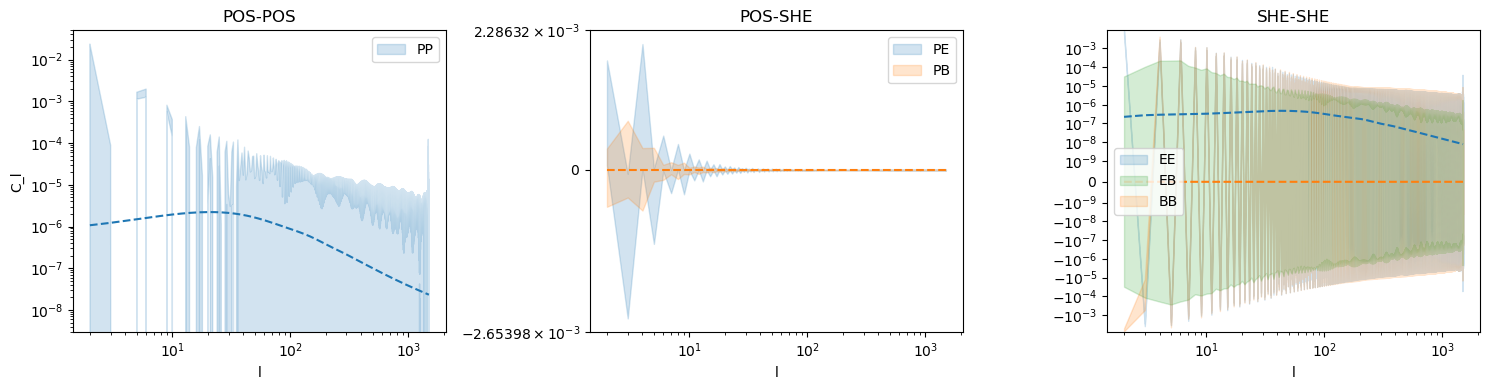

In [39]:
# Create a figure with 1 row and 3 columns of subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 4))  # 1 row, 3 columns

# POS POS
cov_key = ("POS", "POS", "POS", "POS", 1, 1, 1, 1)
err = np.sqrt(inv_ensemble_cov[cov_key].array.diagonal())
axs[0].fill_between(l[2:], 
                    inv_cls_m[("POS", "POS", 1, 1)].array[2:] - err[2:], 
                    inv_cls_m[("POS", "POS", 1, 1)].array[2:] + err[2:],
                    color='C0', alpha=0.2, label='PP')
axs[0].plot(l[2:], _theory_cls[("POS", "POS", 1, 1)].array[2:], color='C0', linestyle='--')
axs[0].legend()
axs[0].set_title("POS-POS")
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel("l")
axs[0].set_ylabel("C_l")

# POS SHE
covkey = ("POS", "SHE", "POS", "SHE", 1, 1, 1, 1)
err = np.sqrt(inv_ensemble_cov[covkey][0, 0].diagonal())
axs[1].fill_between(l[2:],
                    inv_cls_m[("POS", "SHE", 1, 1)].array[0][2:] - err[2:], 
                    inv_cls_m[("POS", "SHE", 1, 1)].array[0][2:] + err[2:],
                    color='C0', alpha=0.2, label='PE')
err = np.sqrt(inv_ensemble_cov[covkey][1, 1].diagonal())
axs[1].fill_between(l[2:],
                    inv_cls_m[("POS", "SHE", 1, 1)].array[1][2:] - err[2:], 
                    inv_cls_m[("POS", "SHE", 1, 1)].array[1][2:] + err[2:],
                    color='C1', alpha=0.2, label='PB')
axs[1].plot(l[2:], _theory_cls[("POS", "SHE", 1, 1)].array[1][2:], color='C1', linestyle='--')
axs[1].legend()
axs[1].set_title("POS-SHE")
axs[1].set_xscale('log')
axs[1].set_yscale('symlog')
axs[1].set_xlabel("l")

# SHE SHE
covkey = ("SHE", "SHE", "SHE", "SHE", 1, 1, 1, 1)
err = np.sqrt(inv_ensemble_cov[covkey][0, 0, 0, 0].diagonal())
axs[2].fill_between(l[2:],
                    inv_cls_m[("SHE", "SHE", 1, 1)].array[0, 0][2:] - err[2:], 
                    inv_cls_m[("SHE", "SHE", 1, 1)].array[0, 0][2:] + err[2:],
                    color='C0', alpha=0.2, label='EE')
err = np.sqrt(inv_ensemble_cov[covkey][0, 1, 0, 1].diagonal())
axs[2].fill_between(l[2:],
                    inv_cls_m[("SHE", "SHE", 1, 1)].array[0, 1][2:] - err[2:], 
                    inv_cls_m[("SHE", "SHE", 1, 1)].array[0, 1][2:] + err[2:],
                    color='C2', alpha=0.2, label='EB')
err = np.sqrt(inv_ensemble_cov[covkey][1, 1, 1, 1].diagonal())
axs[2].fill_between(l[2:],
                    inv_cls_m[("SHE", "SHE", 1, 1)].array[1, 1][2:] - err[2:], 
                    inv_cls_m[("SHE", "SHE", 1, 1)].array[1, 1][2:] + err[2:],
                    color='C1', alpha=0.2, label='BB')
axs[2].plot(l[2:], _theory_cls[("SHE", "SHE", 1, 1)].array[0, 0][2:], color='C0', linestyle='--')
axs[2].plot(l[2:], _theory_cls[("SHE", "SHE", 1, 1)].array[1, 1][2:], color='C1', linestyle='--')
axs[2].legend()
axs[2].set_title("SHE-SHE")
axs[2].set_xscale('log')
axs[2].set_yscale('symlog', linthresh=1e-9)
axs[2].set_xlabel("l")

# Adjust layout
plt.tight_layout()
plt.show()

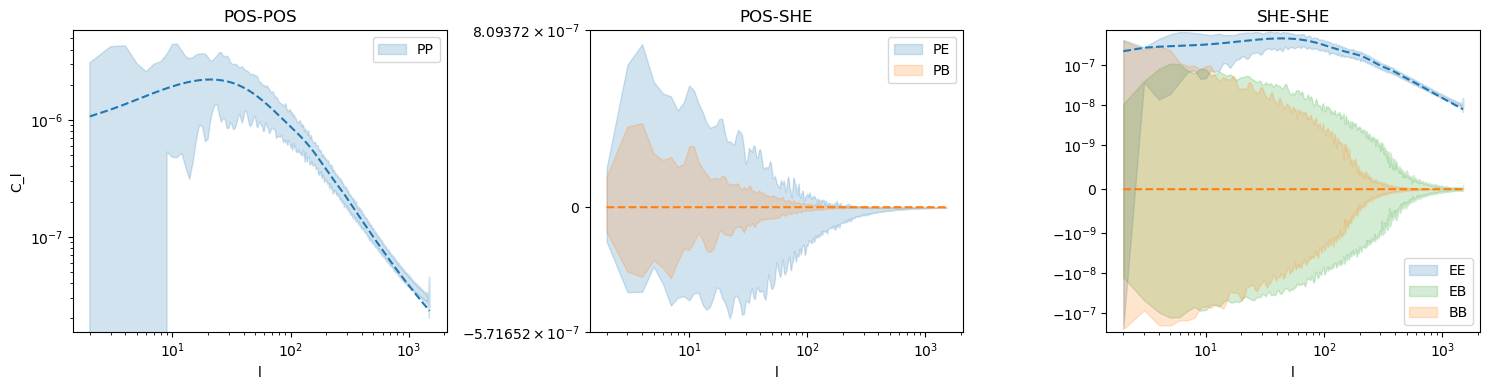

In [34]:
# Create a figure with 1 row and 3 columns of subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 4))  # 1 row, 3 columns

# POS POS
cov_key = ("POS", "POS", "POS", "POS", 1, 1, 1, 1)
err = np.sqrt(nu_ensemble_cov[cov_key].array.diagonal())
axs[0].fill_between(l[2:], 
                    nu_cls_m[("POS", "POS", 1, 1)].array[2:] - err[2:], 
                    nu_cls_m[("POS", "POS", 1, 1)].array[2:] + err[2:],
                    color='C0', alpha=0.2, label='PP')
axs[0].plot(l[2:], _theory_cls[("POS", "POS", 1, 1)].array[2:], color='C0', linestyle='--')
axs[0].legend()
axs[0].set_title("POS-POS")
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel("l")
axs[0].set_ylabel("C_l")

# POS SHE
covkey = ("POS", "SHE", "POS", "SHE", 1, 1, 1, 1)
err = np.sqrt(nu_ensemble_cov[covkey][0, 0].diagonal())
axs[1].fill_between(l[2:],
                    nu_cls_m[("POS", "SHE", 1, 1)].array[0][2:] - err[2:], 
                    nu_cls_m[("POS", "SHE", 1, 1)].array[0][2:] + err[2:],
                    color='C0', alpha=0.2, label='PE')
err = np.sqrt(nu_ensemble_cov[covkey][1, 1].diagonal())
axs[1].fill_between(l[2:],
                    nu_cls_m[("POS", "SHE", 1, 1)].array[1][2:] - err[2:], 
                    nu_cls_m[("POS", "SHE", 1, 1)].array[1][2:] + err[2:],
                    color='C1', alpha=0.2, label='PB')
axs[1].plot(l[2:], _theory_cls[("POS", "SHE", 1, 1)].array[1][2:], color='C1', linestyle='--')
axs[1].legend()
axs[1].set_title("POS-SHE")
axs[1].set_xscale('log')
axs[1].set_yscale('symlog')
axs[1].set_xlabel("l")

# SHE SHE
covkey = ("SHE", "SHE", "SHE", "SHE", 1, 1, 1, 1)
err = np.sqrt(nu_ensemble_cov[covkey][0, 0, 0, 0].diagonal())
axs[2].fill_between(l[2:],
                    nu_cls_m[("SHE", "SHE", 1, 1)].array[0, 0][2:] - err[2:], 
                    nu_cls_m[("SHE", "SHE", 1, 1)].array[0, 0][2:] + err[2:],
                    color='C0', alpha=0.2, label='EE')
err = np.sqrt(nu_ensemble_cov[covkey][0, 1, 0, 1].diagonal())
axs[2].fill_between(l[2:],
                    nu_cls_m[("SHE", "SHE", 1, 1)].array[0, 1][2:] - err[2:], 
                    nu_cls_m[("SHE", "SHE", 1, 1)].array[0, 1][2:] + err[2:],
                    color='C2', alpha=0.2, label='EB')
err = np.sqrt(nu_ensemble_cov[covkey][1, 1, 1, 1].diagonal())
axs[2].fill_between(l[2:],
                    nu_cls_m[("SHE", "SHE", 1, 1)].array[1, 1][2:] - err[2:], 
                    nu_cls_m[("SHE", "SHE", 1, 1)].array[1, 1][2:] + err[2:],
                    color='C1', alpha=0.2, label='BB')
axs[2].plot(l[2:], _theory_cls[("SHE", "SHE", 1, 1)].array[0, 0][2:], color='C0', linestyle='--')
axs[2].plot(l[2:], _theory_cls[("SHE", "SHE", 1, 1)].array[1, 1][2:], color='C1', linestyle='--')
axs[2].legend()
axs[2].set_title("SHE-SHE")
axs[2].set_xscale('log')
axs[2].set_yscale('symlog', linthresh=1e-9)
axs[2].set_xlabel("l")

# Adjust layout
plt.tight_layout()
plt.show()

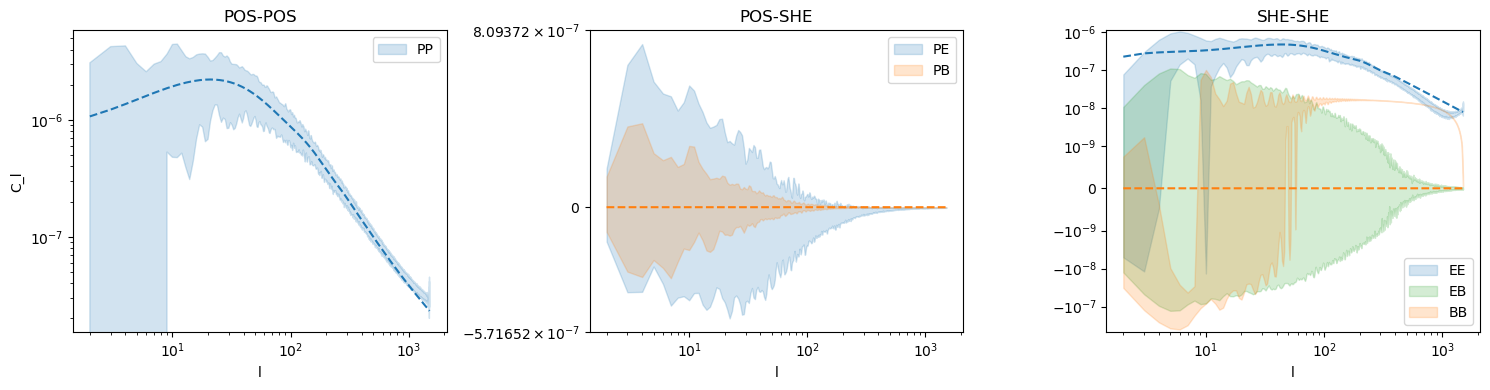

In [36]:
# Create a figure with 1 row and 3 columns of subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 4))  # 1 row, 3 columns

# POS POS
cov_key = ("POS", "POS", "POS", "POS", 1, 1, 1, 1)
err = np.sqrt(pp_ensemble_cov[cov_key].array.diagonal())
axs[0].fill_between(l[2:], 
                    pp_cls_m[("POS", "POS", 1, 1)].array[2:] - err[2:], 
                    pp_cls_m[("POS", "POS", 1, 1)].array[2:] + err[2:],
                    color='C0', alpha=0.2, label='PP')
axs[0].plot(l[2:], _theory_cls[("POS", "POS", 1, 1)].array[2:], color='C0', linestyle='--')
axs[0].legend()
axs[0].set_title("POS-POS")
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel("l")
axs[0].set_ylabel("C_l")

# POS SHE
covkey = ("POS", "SHE", "POS", "SHE", 1, 1, 1, 1)
err = np.sqrt(pp_ensemble_cov[covkey][0, 0].diagonal())
axs[1].fill_between(l[2:],
                    pp_cls_m[("POS", "SHE", 1, 1)].array[0][2:] - err[2:], 
                    pp_cls_m[("POS", "SHE", 1, 1)].array[0][2:] + err[2:],
                    color='C0', alpha=0.2, label='PE')
err = np.sqrt(pp_ensemble_cov[covkey][1, 1].diagonal())
axs[1].fill_between(l[2:],
                    pp_cls_m[("POS", "SHE", 1, 1)].array[1][2:] - err[2:], 
                    pp_cls_m[("POS", "SHE", 1, 1)].array[1][2:] + err[2:],
                    color='C1', alpha=0.2, label='PB')
axs[1].plot(l[2:], _theory_cls[("POS", "SHE", 1, 1)].array[1][2:], color='C1', linestyle='--')
axs[1].legend()
axs[1].set_title("POS-SHE")
axs[1].set_xscale('log')
axs[1].set_yscale('symlog')
axs[1].set_xlabel("l")

# SHE SHE
covkey = ("SHE", "SHE", "SHE", "SHE", 1, 1, 1, 1)
err = np.sqrt(pp_ensemble_cov[covkey][0, 0, 0, 0].diagonal())
axs[2].fill_between(l[2:],
                    pp_cls_m[("SHE", "SHE", 1, 1)].array[0, 0][2:] - err[2:], 
                    pp_cls_m[("SHE", "SHE", 1, 1)].array[0, 0][2:] + err[2:],
                    color='C0', alpha=0.2, label='EE')
err = np.sqrt(pp_ensemble_cov[covkey][0, 1, 0, 1].diagonal())
axs[2].fill_between(l[2:],
                    pp_cls_m[("SHE", "SHE", 1, 1)].array[0, 1][2:] - err[2:], 
                    pp_cls_m[("SHE", "SHE", 1, 1)].array[0, 1][2:] + err[2:],
                    color='C2', alpha=0.2, label='EB')
err = np.sqrt(pp_ensemble_cov[covkey][1, 1, 1, 1].diagonal())
axs[2].fill_between(l[2:],
                    pp_cls_m[("SHE", "SHE", 1, 1)].array[1, 1][2:] - err[2:], 
                    pp_cls_m[("SHE", "SHE", 1, 1)].array[1, 1][2:] + err[2:],
                    color='C1', alpha=0.2, label='BB')
axs[2].plot(l[2:], _theory_cls[("SHE", "SHE", 1, 1)].array[0, 0][2:], color='C0', linestyle='--')
axs[2].plot(l[2:], _theory_cls[("SHE", "SHE", 1, 1)].array[1, 1][2:], color='C1', linestyle='--')
axs[2].legend()
axs[2].set_title("SHE-SHE")
axs[2].set_xscale('log')
axs[2].set_yscale('symlog', linthresh=1e-9)
axs[2].set_xlabel("l")

# Adjust layout
plt.tight_layout()
plt.show()

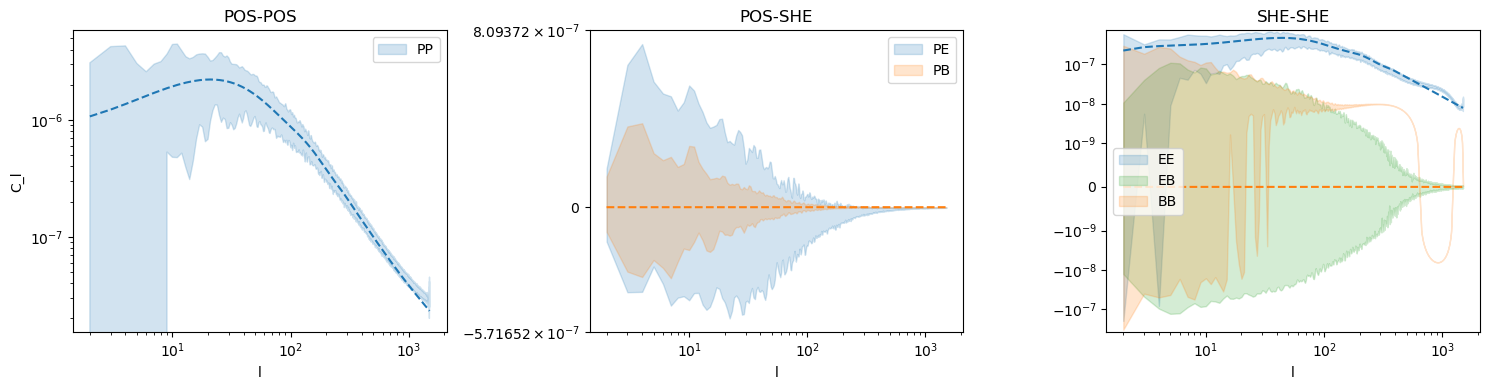

In [38]:
# Create a figure with 1 row and 3 columns of subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 4))  # 1 row, 3 columns

# POS POS
cov_key = ("POS", "POS", "POS", "POS", 1, 1, 1, 1)
err = np.sqrt(pm_ensemble_cov[cov_key].array.diagonal())
axs[0].fill_between(l[2:], 
                    pm_cls_m[("POS", "POS", 1, 1)].array[2:] - err[2:], 
                    pm_cls_m[("POS", "POS", 1, 1)].array[2:] + err[2:],
                    color='C0', alpha=0.2, label='PP')
axs[0].plot(l[2:], _theory_cls[("POS", "POS", 1, 1)].array[2:], color='C0', linestyle='--')
axs[0].legend()
axs[0].set_title("POS-POS")
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel("l")
axs[0].set_ylabel("C_l")

# POS SHE
covkey = ("POS", "SHE", "POS", "SHE", 1, 1, 1, 1)
err = np.sqrt(pm_ensemble_cov[covkey][0, 0].diagonal())
axs[1].fill_between(l[2:],
                    pm_cls_m[("POS", "SHE", 1, 1)].array[0][2:] - err[2:], 
                    pm_cls_m[("POS", "SHE", 1, 1)].array[0][2:] + err[2:],
                    color='C0', alpha=0.2, label='PE')
err = np.sqrt(pm_ensemble_cov[covkey][1, 1].diagonal())
axs[1].fill_between(l[2:],
                    pm_cls_m[("POS", "SHE", 1, 1)].array[1][2:] - err[2:], 
                    pm_cls_m[("POS", "SHE", 1, 1)].array[1][2:] + err[2:],
                    color='C1', alpha=0.2, label='PB')
axs[1].plot(l[2:], _theory_cls[("POS", "SHE", 1, 1)].array[1][2:], color='C1', linestyle='--')
axs[1].legend()
axs[1].set_title("POS-SHE")
axs[1].set_xscale('log')
axs[1].set_yscale('symlog')
axs[1].set_xlabel("l")

# SHE SHE
covkey = ("SHE", "SHE", "SHE", "SHE", 1, 1, 1, 1)
err = np.sqrt(pm_ensemble_cov[covkey][0, 0, 0, 0].diagonal())
axs[2].fill_between(l[2:],
                    pm_cls_m[("SHE", "SHE", 1, 1)].array[0, 0][2:] - err[2:], 
                    pm_cls_m[("SHE", "SHE", 1, 1)].array[0, 0][2:] + err[2:],
                    color='C0', alpha=0.2, label='EE')
err = np.sqrt(pm_ensemble_cov[covkey][0, 1, 0, 1].diagonal())
axs[2].fill_between(l[2:],
                    pm_cls_m[("SHE", "SHE", 1, 1)].array[0, 1][2:] - err[2:], 
                    pm_cls_m[("SHE", "SHE", 1, 1)].array[0, 1][2:] + err[2:],
                    color='C2', alpha=0.2, label='EB')
err = np.sqrt(pm_ensemble_cov[covkey][1, 1, 1, 1].diagonal())
axs[2].fill_between(l[2:],
                    pm_cls_m[("SHE", "SHE", 1, 1)].array[1, 1][2:] - err[2:], 
                    pm_cls_m[("SHE", "SHE", 1, 1)].array[1, 1][2:] + err[2:],
                    color='C1', alpha=0.2, label='BB')
axs[2].plot(l[2:], _theory_cls[("SHE", "SHE", 1, 1)].array[0, 0][2:], color='C0', linestyle='--')
axs[2].plot(l[2:], _theory_cls[("SHE", "SHE", 1, 1)].array[1, 1][2:], color='C1', linestyle='--')
axs[2].legend()
axs[2].set_title("SHE-SHE")
axs[2].set_xscale('log')
axs[2].set_yscale('symlog', linthresh=1e-9)
axs[2].set_xlabel("l")

# Adjust layout
plt.tight_layout()
plt.show()

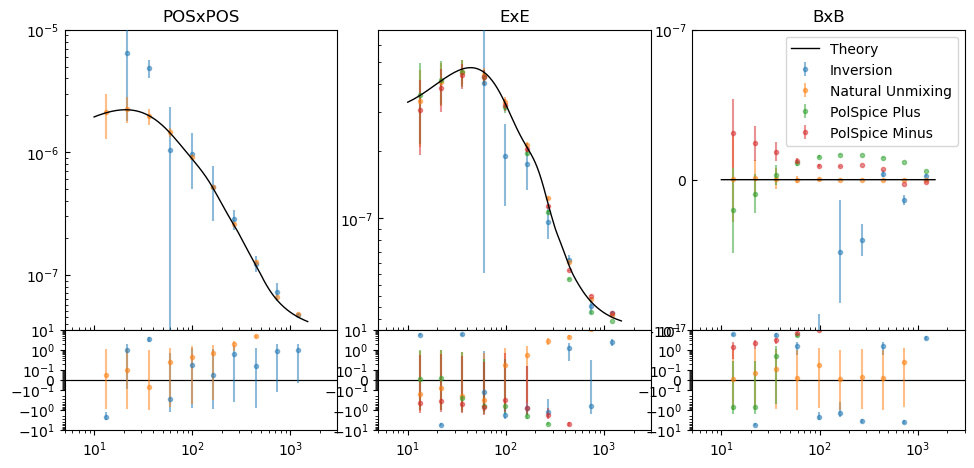

In [18]:
fig, ax = plt.subplots(2, 3, figsize=(9, 4), gridspec_kw={"height_ratios": [3, 1]})
fig.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0, wspace=0.15, hspace=0.0)

# POS
key = ("POS", "POS", 1, 1)
cov_key = ("POS", "POS", "POS", "POS", 1, 1, 1, 1)

i_cov = inv_ensemble_covqq[cov_key]
nu_cov = nu_ensemble_covqq[cov_key]
pp_cov = pp_ensemble_covqq[cov_key]
pm_cov = pm_ensemble_covqq[cov_key]

i_err = np.sqrt(np.diag(i_cov))
nu_err = np.sqrt(np.diag(nu_cov))
pp_err = np.sqrt(np.diag(pp_cov))
pm_err = np.sqrt(np.diag(pm_cov))

i_c = inv_cqs_m[key]
nu_c = nu_cqs_m[key]
pp_c = pp_cqs_m[key]
pm_c = pm_cqs_m[key]
t = _theory_cls[key]
t_itp = np.interp(lgrid, ls, t)


ax[0, 0].errorbar(
            lgrid, i_c, yerr=i_err, fmt=".", c="C0", lw=1.5, zorder=3.0, alpha=0.5,
            label="Inversion"
        )
ax[0, 0].errorbar(
    lgrid, nu_c, yerr=nu_err, fmt=".", c="C1", lw=1.5, zorder=3.0, alpha=0.5,
    label="Natural Unmixing"
        )
ax[0, 0].plot(ls[10:], t[10:], c="k", lw=1.0, zorder=4.0)
ax[1, 0].axhline(0.0, c="k", lw=0.8, zorder=-1)
ax[1, 0].errorbar(
    lgrid,
    (i_c - t_itp) / i_err,
    yerr=np.abs(i_err / i_err),
    fmt=".",
    c="C0",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 0].errorbar(
    lgrid,
    (nu_c - t_itp) / nu_err,
    yerr=np.abs(nu_err / nu_err),
    fmt=".",
    c="C1",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 0].axhline(0.0, c="k", lw=0.8, zorder=-1)

ax[0, 0].tick_params(axis="both", which="both", direction="in")
ax[0, 0].set_yscale(
    "symlog", linthresh=1e-7, linscale=0.45, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_ylim(-5e-4, 5e-3)
ax[1, 0].set_yscale(
    "symlog", linthresh=0.1, linscale=0.45, subs=np.arange(0.1, 1.0, 0.1)
)
ax[1, 0].set_ylim(-10, 10)

ax[0, 0].set_ylim(1e-8, 1e-5)
ax[0, 0].set_title("POSxPOS")
ax[0, 0].set_xscale("log")
ax[0, 0].set_xlim(5, lmax * 2)
ax[1, 0].set_xscale("log")
ax[1, 0].set_xlim(5, lmax * 2)

# SHE-E
key = ("SHE", "SHE", 1, 1)
cov_key = ("SHE", "SHE", "SHE", "SHE", 1, 1, 1, 1)

i_cov = inv_ensemble_covqq[cov_key][0, 0, 0, 0, :, :]
nu_cov = nu_ensemble_covqq[cov_key][0, 0, 0, 0, :, :]
pp_cov = pp_ensemble_covqq[cov_key][0, 0, 0, 0, :, :]
pm_cov = pm_ensemble_covqq[cov_key][0, 0, 0, 0, :, :]

i_err = np.sqrt(np.diag(i_cov))
nu_err = np.sqrt(np.diag(nu_cov))
pp_err = np.sqrt(np.diag(pp_cov))
pm_err = np.sqrt(np.diag(pm_cov))

i_c = inv_cqs_m[key][0, 0, :]
nu_c = nu_cqs_m[key][0, 0, :]
pp_c = pp_cqs_m[key][0, 0, :]
pm_c = pm_cqs_m[key][0, 0, :]
t = _theory_cls[key][0, 0, :]
t_itp = np.interp(lgrid, ls, t)

ax[0, 1].errorbar(
            lgrid, i_c, yerr=i_err, fmt=".", c="C0", lw=1.5, zorder=3.0, alpha=0.5,
            label="Inversion"
        )
ax[0, 1].errorbar(
    lgrid, nu_c, yerr=nu_err, fmt=".", c="C1", lw=1.5, zorder=3.0, alpha=0.5,
    label="Natural Unmixing"
        )
ax[0, 1].errorbar(
    lgrid, pp_c, yerr=pp_err, fmt=".", c="C2", lw=1.5, zorder=3.0, alpha=0.5,
    label="PolSpice Plus"
        )
ax[0, 1].errorbar(
    lgrid, pm_c, yerr=pm_err, fmt=".", c="C3", lw=1.5, zorder=3.0, alpha=0.5,
    label="PolSpice Minus"
        )
ax[0, 1].plot(ls[10:], t[10:], c="k", lw=1.0, zorder=4.0)
ax[1, 1].axhline(0.0, c="k", lw=0.8, zorder=-1)
ax[1, 1].errorbar(
    lgrid,
    (i_c - t_itp) / i_err,
    yerr=np.abs(i_err / i_err),
    fmt=".",
    c="C0",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 1].errorbar(
    lgrid,
    (nu_c - t_itp) / nu_err,
    yerr=np.abs(nu_err / nu_err),
    fmt=".",
    c="C1",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 1].errorbar(
    lgrid,
    (pp_c - t_itp) / pp_err,
    yerr=np.abs(pp_err / pp_err),
    fmt=".",
    c="C2",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 1].errorbar(
    lgrid,
    (pm_c - t_itp) / pm_err,
    yerr=np.abs(pm_err / pm_err),
    fmt=".",
    c="C3",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 1].axhline(0.0, c="k", lw=0.8, zorder=-1)

ax[0, 1].tick_params(axis="both", which="both", direction="in")
ax[0, 1].set_yscale(
    "symlog", linthresh=1e-7, linscale=0.45, subs=np.arange(0.1, 1.0, 0.1)
)
ax[1, 1].set_yscale(
    "symlog", linthresh=0.1, linscale=0.45, subs=np.arange(0.1, 1.0, 0.1)
)
ax[1, 1].set_ylim(-10, 10)
ax[0, 1].set_ylim(1e-11, 7e-7)
ax[0, 1].set_title("ExE")
ax[0, 1].set_xscale("log")
ax[0, 1].set_xlim(5, lmax * 2)
ax[1, 1].set_xscale("log")
ax[1, 1].set_xlim(5, lmax * 2)

# SHE-B
key = ("SHE", "SHE", 1, 1)
cov_key = ("SHE", "SHE", "SHE", "SHE", 1, 1, 1, 1)

i_cov = inv_ensemble_covqq[cov_key][1, 1, 1, 1, :, :]
nu_cov = nu_ensemble_covqq[cov_key][1, 1, 1, 1, :, :]
pp_cov = pp_ensemble_covqq[cov_key][1, 1, 1, 1, :, :]
pm_cov = pm_ensemble_covqq[cov_key][1, 1, 1, 1, :, :]

i_err = np.sqrt(np.diag(i_cov))
nu_err = np.sqrt(np.diag(nu_cov))
pp_err = np.sqrt(np.diag(pp_cov))
pm_err = np.sqrt(np.diag(pm_cov))

i_c = inv_cqs_m[key][1, 1, :]
nu_c = nu_cqs_m[key][1, 1, :]
pp_c = pp_cqs_m[key][1, 1, :]
pm_c = pm_cqs_m[key][1, 1, :]
t = _theory_cls[key][1, 1, :]
t_itp = np.interp(lgrid, ls, t)

ax[0, 2].errorbar(
            lgrid, i_c, yerr=i_err, fmt=".", c="C0", lw=1.5, zorder=3.0, alpha=0.5,
            label="Inversion"
        )
ax[0, 2].errorbar(
    lgrid, nu_c, yerr=nu_err, fmt=".", c="C1", lw=1.5, zorder=3.0, alpha=0.5,
    label="Natural Unmixing"
        )
ax[0, 2].errorbar(
    lgrid, pp_c, yerr=pp_err, fmt=".", c="C2", lw=1.5, zorder=3.0, alpha=0.5,
    label="PolSpice Plus"
        )
ax[0, 2].errorbar(
    lgrid, pm_c, yerr=pm_err, fmt=".", c="C3", lw=1.5, zorder=3.0, alpha=0.5,
    label="PolSpice Minus"
        )
ax[0, 2].plot(ls[10:], t[10:], c="k", lw=1.0, zorder=4.0, label="Theory")
ax[1, 2].axhline(0.0, c="k", lw=0.8, zorder=-1)
ax[1, 2].errorbar(
    lgrid,
    (i_c - t_itp) / i_err,
    yerr=np.abs(i_err / i_err),
    fmt=".",
    c="C0",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 2].errorbar(
    lgrid,
    (nu_c - t_itp) / nu_err,
    yerr=np.abs(nu_err / nu_err),
    fmt=".",
    c="C1",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 2].errorbar(
    lgrid,
    (pp_c - t_itp) / pp_err,
    yerr=np.abs(pp_err / pp_err),
    fmt=".",
    c="C2",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 2].errorbar(
    lgrid,
    (pm_c - t_itp) / pm_err,
    yerr=np.abs(pm_err / pm_err),
    fmt=".",
    c="C3",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[0, 2].legend()
ax[0, 2].set_title("BxB")
ax[1, 2].axhline(0.0, c="k", lw=0.8, zorder=-1)

ax[0, 2].tick_params(axis="both", which="both", direction="in")
ax[0, 2].set_yscale(
    "symlog", linthresh=1e-7, linscale=0.45, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 2].set_ylim(-1e-7, 1e-7)
ax[1, 2].set_yscale(
    "symlog", linthresh=0.1, linscale=0.45, subs=np.arange(0.1, 1.0, 0.1)
)
ax[1, 2].set_ylim(-10, 10)

ax[0, 2].set_xscale("log")
ax[0, 2].set_xlim(5, lmax * 2)
ax[1, 2].set_xscale("log")
ax[1, 2].set_xlim(5, lmax * 2)
fig.savefig('/home/jaimerzp/Desktop/mixing_mat_plots/cls_compo.pdf', bbox_inches='tight')